# Clase 01 · Práctica 01 — Densidad en dos lunas sintéticas

**Pregunta:** ¿cómo cambian grupos y ruido cuando cambian parámetros, perturbación o tamaño muestral? Primero exploramos atributos con ArcGIS; después conservamos NumPy, pandas, Matplotlib y scikit-learn de la fuente para el experimento controlado. Requisito: entorno ArcGIS Pro 3.6.2 autorizado, sin instalar paquetes. Dependencia local explícita: `clase01_arcgis.py`, junto a este notebook. Reinicie el kernel y ejecute todas las celdas.

**Excepción pedagógica acotada aprobada por el usuario:** «la practica sintética dejmemosla sintetica sin datos geograficos, usemos moon de sklearn o loq ue se menciona ahi». Aquí no se cargan datos territoriales, no se asigna referencia espacial y no se fabrican mapas. Los gráficos tabulares ArcGIS siguen siendo obligatorios. Esta excepción no cambia los requisitos geográficos de P02.

Fuente: notebook Clase 13, celdas 4–13, y V13 (23/06/2026), 01:08:11–01:39:38. Identidades y referencias E3–E5/E12–E13: [Fuentes y acuerdos](../Clase%2001%20-%20Fuentes%20y%20acuerdos.md). Resultados de aquella fuente no se reutilizan como observaciones actuales.

La configuración siguiente es la única celda para rutas. Cada ejecución crea un directorio nuevo; ninguna depende de P02.

## Objetivos
- Distinguir ruido generador, ruido del modelo y tipos de punto.
- Comparar parámetros y métricas sin confundir sensibilidad con exactitud.


**Ejecución observada de esta revisión:** 11/11 celdas; 19.426 s; 9 PNG incrustados; retorno natural **0**. Proceso Python de ArcGIS Pro con captura MIME; no prueba una sesión interactiva Jupyter/VS Code. Carpeta: `ejecucion_20260916T221000_47d05679`.

**Presentación aún en revisión:** faltan ajustes y comprobaciones visuales; esto no es entrega académica final. La licencia bloqueó la continuación de las dos últimas prácticas. La captura sin InteractiveShell evitó el error fatal GIL en tres procesos, pero no certifica un kernel interactivo sano.

### Configuración y estado de esta revisión
La primera celda solo define rutas. `ROOT = None` busca ambos marcadores desde la carpeta actual o sus ancestros. Si Jupyter inicia fuera del vault, sustituya **esa primera asignación** por `ROOT = Path(...)` con la ruta absoluta de su copia; no use `__file__`. `DATA_DIR` y `OUTPUT_DIR` admiten rutas externas absolutas: cambie sus asignaciones aquí y mantenga entradas y salidas separadas. En Bomberos P02, `PREPARED_JURIS` configura la entrada preparada por separado. La plantilla se obtiene de la instalación de Pro. El preflight muestra nombre, ruta resuelta y existencia antes de crear salidas; no instala ArcPy ni obtiene licencia automáticamente.

**Estado N02:** salidas y cifras incrustadas son **históricas, referencia histórica; salida actual arriba/abajo** (ejecución final completa). Las pruebas de rutas no ejecutan modelos. Pendientes N03 (visualización) y N05 (verificación independiente). Se conservan registros previos: cero errores de celda no demuestra cierre natural; el cierre forzado del driver histórico de Clase 02 tampoco lo acredita.


In [1]:
# ROOT=None busca el vault; fuera de él escriba aquí Path con su ruta absoluta.
from pathlib import Path
ROOT = None
ROOT = Path(ROOT).expanduser().resolve() if ROOT is not None else next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'AGENTS.md').is_file() and (p/'99 - Recursos/notebooks').is_dir()), None)
if ROOT is None or not (ROOT/'AGENTS.md').is_file() or not (ROOT/'99 - Recursos/notebooks').is_dir():
    raise FileNotFoundError('No se encontró el vault (AGENTS.md + 99 - Recursos/notebooks). Edite ROOT = Path con la ruta absoluta del vault; no use __file__.')
VAULT_DIR = ROOT  # Alias conservado del auxiliar declarado.
DATA_DIR = VAULT_DIR / '99 - Recursos/datos'
OUTPUT_DIR = VAULT_DIR / '99 - Recursos/salidas_clase_01/practica_01'


### Preflight de solo lectura
Comprobar kernel, licencia y requisitos antes de crear salidas. Cada ausencia se informa por su nombre y ruta exactos.

In [2]:
# Solo lectura: comprobar kernel, licencia y cada ruta antes de crear salidas.
try:
    import arcpy
except Exception as exc:
    raise RuntimeError('ArcPy no disponible. Seleccione el kernel Python de ArcGIS Pro con licencia y reinícielo; no se instala automáticamente.') from exc
try:
    INFO_PRO = arcpy.GetInstallInfo()
    LICENCIA = arcpy.ProductInfo()
except Exception as exc:
    raise RuntimeError('No se pudo inicializar Pro. Revise instalación y acceso a licencia antes de modelar.') from exc
print('ArcGIS Pro:', INFO_PRO.get('Version'), '| licencia:', LICENCIA)
if LICENCIA not in ('ArcView', 'ArcEditor', 'ArcInfo'):
    raise RuntimeError('Licencia no inicializada: ' + str(LICENCIA))
AUXILIAR = ROOT / '99 - Recursos/notebooks/clase01_arcgis.py'
REQUERIDOS = [('Auxiliar local clase01_arcgis.py', AUXILIAR, True)]
faltantes = []
for nombre, ruta, es_archivo in REQUERIDOS:
    ruta = Path(ruta).resolve()
    existe = ruta.is_file() if es_archivo else bool(arcpy.Exists(str(ruta)))
    print(f'{nombre} | {ruta} | existe={existe}')
    if not existe:
        faltantes.append(f'{nombre}: {ruta}')
if faltantes:
    raise FileNotFoundError('Entradas ausentes; ajuste la configuración sin sustituir datos: ' + '; '.join(faltantes))


ArcGIS Pro: 3.6.2 | licencia: ArcInfo
Auxiliar local clase01_arcgis.py | C:\Users\ecetina\OneDrive - Esri NOSA\diplomado_geoia_v3\99 - Recursos\notebooks\clase01_arcgis.py | existe=True


**Lectura:** `existe=True` indica disponibilidad, no calidad geométrica ni resultados. **Compruebe:** ¿usa el kernel de Pro y la entrada autorizada?

### Bibliotecas y salidas
Después del preflight se importa el auxiliar declarado y se crea una corrida aislada; no depende de otro notebook.

In [3]:
# NumPy maneja máscaras; pandas resume; sklearn conserva los métodos de la fuente.
import sys, time
sys.path.insert(0, str(VAULT_DIR / '99 - Recursos/notebooks'))
import clase01_arcgis as apoyo
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Segoe UI', 'text.color': '#142b40', 'axes.labelcolor': '#142b40', 'figure.facecolor': 'white', 'font.size': 11})
import arcpy
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, HDBSCAN
from IPython.display import Image, display, Markdown
inicio = time.perf_counter()
RUN_DIR = apoyo.new_run(DATA_DIR, OUTPUT_DIR, [VAULT_DIR / 'Datos'])
work_gdb = apoyo.configure_arcpy(RUN_DIR)


## 1. Generar y explorar antes de modelar

`make_moons` genera dos semicírculos y perturba sus posiciones. **noise=0.9999** es la desviación de esa perturbación gaussiana; no es el porcentaje de ruido del algoritmo. `random_state=10` fija la realización; se generan **200**, no los 300 del mensaje erróneo de la fuente. La etiqueta generadora describe origen sintético, no una verdad territorial.

ArcGIS primero: CSV local → Field Statistics To Table → Scatter. Se esperan campos numéricos completos y 200 filas; la ejecución debe comprobarlos, no asumirlos. La dispersión representa el espacio de atributos.

Respaldo: scikit-learn 1.6, [make_moons, Parameters](https://scikit-learn.org/1.6/modules/generated/sklearn.datasets.make_moons.html), E13; Esri Pro 3.6, [Field Statistics To Table, Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/field-statistics-to-table.htm) y [Scatter, Parameters/exportToPNG](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/scatter.htm). Leídos por el orquestador el 15/09/2026; no nueva consulta web de este escritor.

**Antes del perfil:** Campo/Tipo identifican atributos, COUNT cuenta valores presentes, NULLS ausentes y Únicos valores distintos. Mínimo/máximo delimitan el rango de cada atributo sin unidad física; no son coordenadas territoriales. Un cero es un valor válido, no ausencia. El auxiliar exporta únicamente estos descriptivos, no medias de Grupo. La tabla será visible al reejecutar; no se inventan sus extremos históricos.

Filas sintéticas generadas: 200 | Valores no finitos: 0


,Campo,Tipo,Conteo,Nulos,Únicos,Mínimo,Máximo
0,Variable1,Double,200,0,200,-3.5084113572923297,4.7809594289575035
1,Variable2,Double,200,0,200,-1.9930833577908822,3.3381062353594797


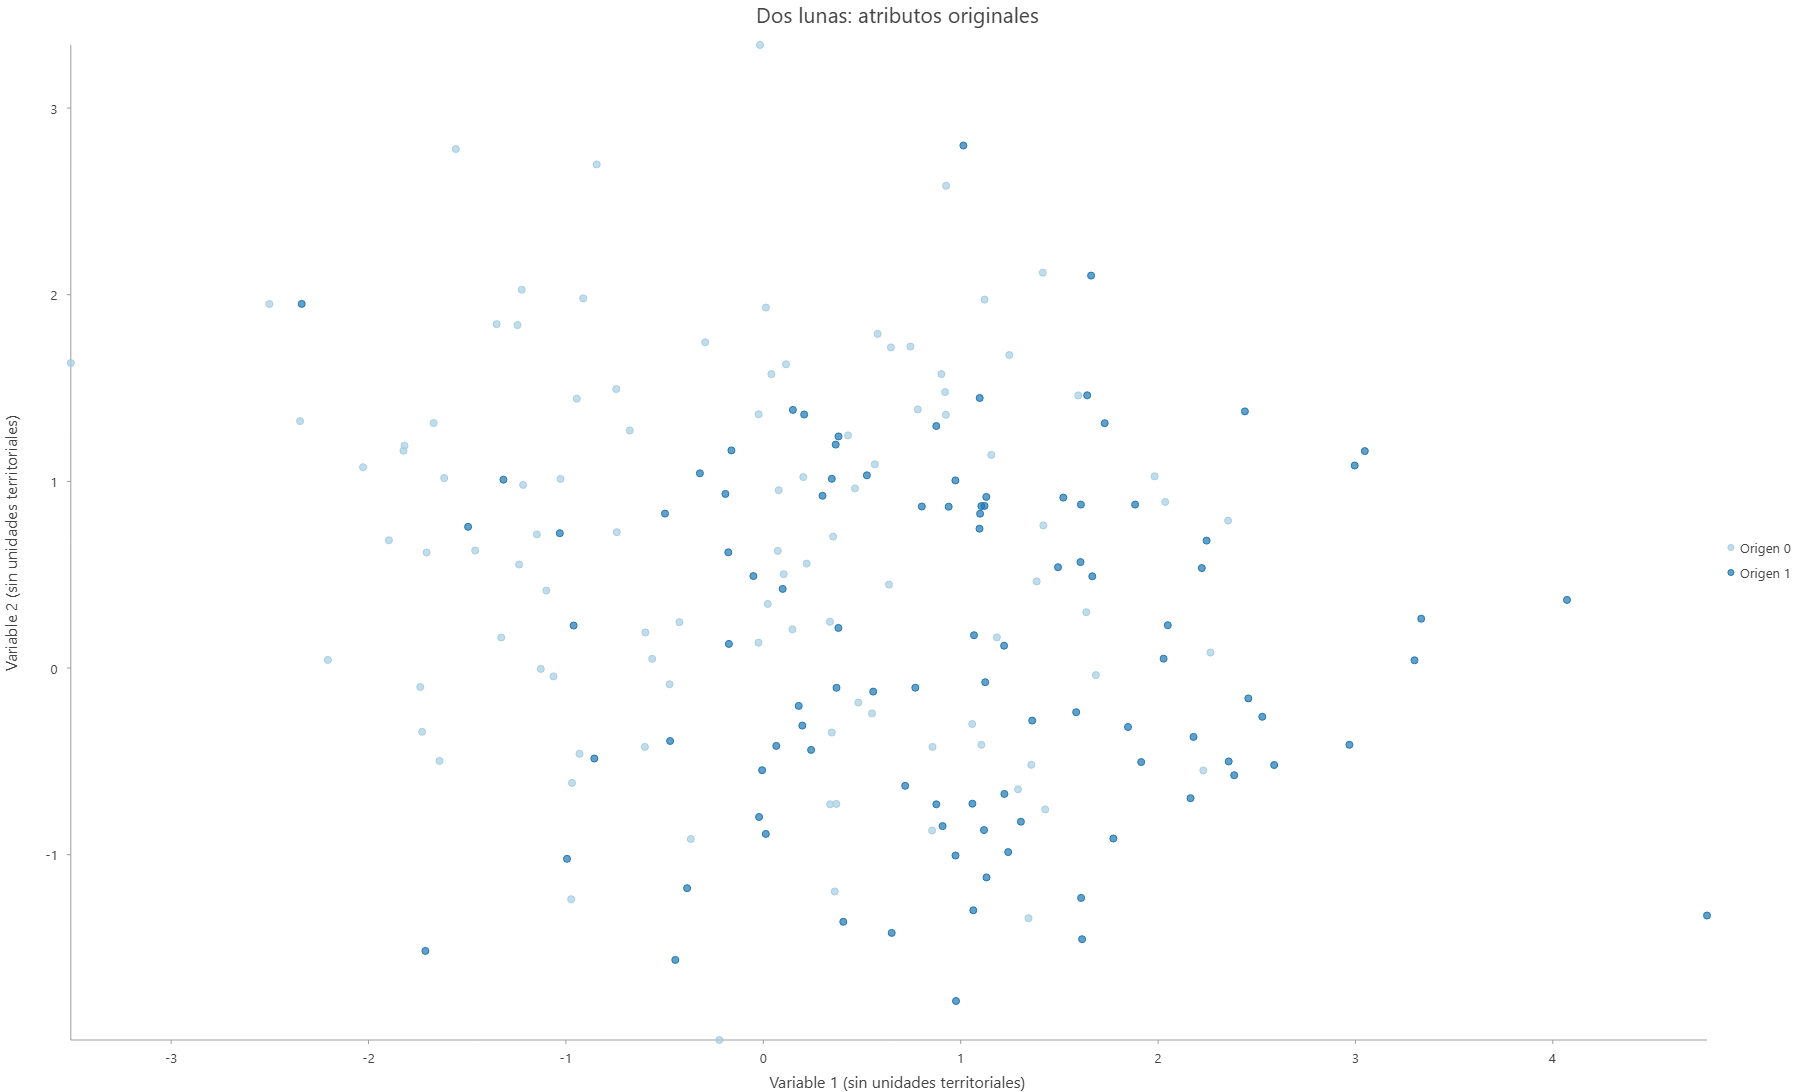

In [4]:
# La longitud calculada corrige el mensaje histórico sin modificar el original.
X, y_true = make_moons(n_samples=200, noise=0.9999, random_state=10)
df = pd.DataFrame(X, columns=['Variable1', 'Variable2'])
df['Grupo'] = ['Origen ' + str(v) for v in y_true]
raw_csv = RUN_DIR / 'lunas_originales.csv'
df.to_csv(raw_csv, index=False, encoding='utf-8')
perfil = apoyo.native_profile(raw_csv, ['Variable1', 'Variable2'], work_gdb, 'perfil_lunas')
# Mostrar el perfil nativo ya calculado, sin volver a ejecutar estadísticas.
with arcpy.da.SearchCursor(perfil, ['campo', 'tipo', 'conteo', 'nulos', 'unicos', 'minimo', 'maximo']) as cursor:
    display(pd.DataFrame(list(cursor), columns=['Campo', 'Tipo', 'Conteo', 'Nulos', 'Únicos', 'Mínimo', 'Máximo']))
assert len(df) == 200 and np.isfinite(X).all()
print('Filas sintéticas generadas:', len(df), '| Valores no finitos:', int((~np.isfinite(X)).sum()))
display(Image(width=1100, filename=str(apoyo.scatter_csv(df, RUN_DIR, 'arcgis_original', 'Dos lunas: atributos originales'))))


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** Se generaron 200 filas y 0 valores no finitos. Variable1/Variable2 son atributos continuos sin unidad física y Grupo es una categoría generadora. No hay fecha ni CRS. La nube puede solaparse pese a sus dos orígenes: completitud numérica no garantiza separabilidad. ¿Por qué un color de origen no prueba un grupo recuperable?

### Leer las escalas

Los colores anteriores indican el semicírculo generador, no grupos descubiertos. Con perturbación alta pueden solaparse. `StandardScaler.fit_transform` resta la media y divide por la desviación de cada atributo (E12, scikit-learn 1.6, [StandardScaler, definición](https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.StandardScaler.html)). Conservamos esta decisión de la fuente; los ejes resultantes son adimensionales. **Estandarizar no vuelve normal una distribución** y no debe trasladarse automáticamente a distancias en metros.

Compare los ejes y la nube antes/después: cambia la métrica entre atributos, no su origen. El gráfico ArcGIS siguiente no es un mapa.

Medias estandarizadas: [-0.0, -0.0]
Desviaciones con divisor N: [1.0, 1.0]


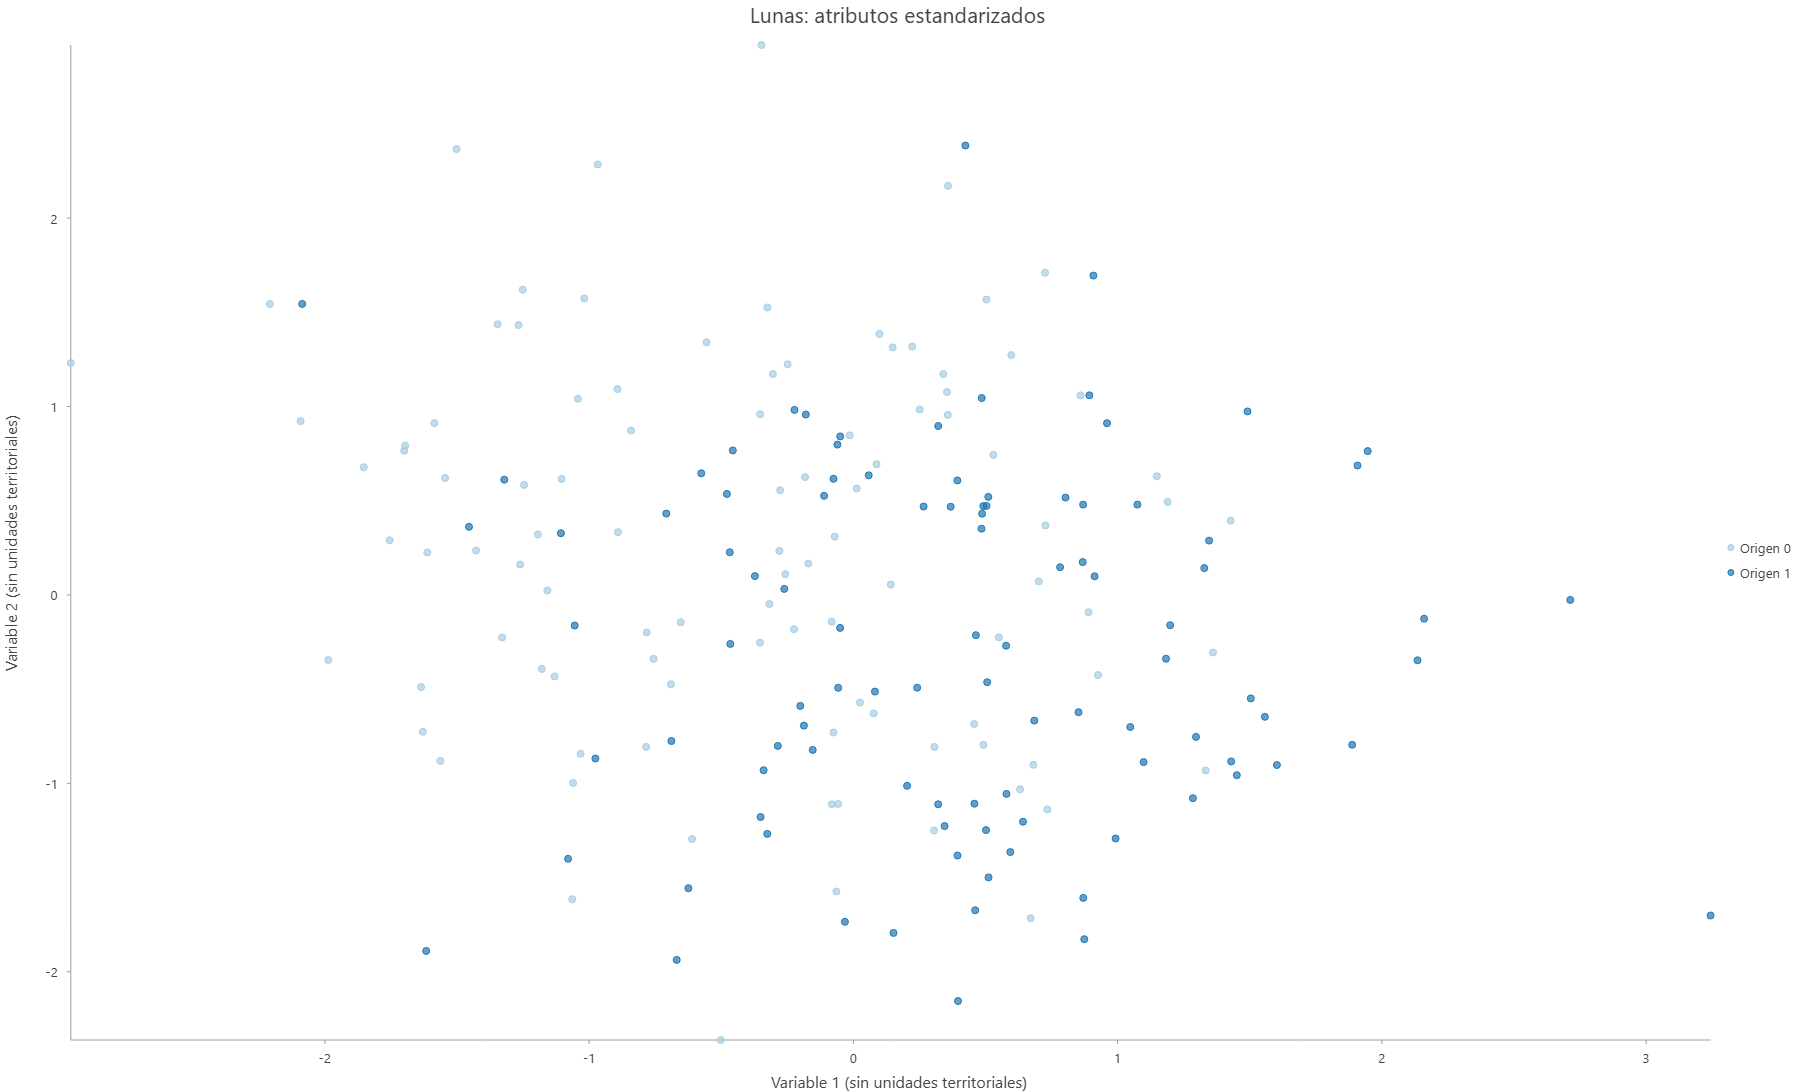

In [5]:
# Ajuste independiente a esta realización; la salida conserva las 200 observaciones.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Variable1', 'Variable2']])
scaled_df = pd.DataFrame(X_scaled, columns=['Variable1', 'Variable2'])
scaled_df['Grupo'] = df['Grupo']
display(Image(width=1100, filename=str(apoyo.scatter_csv(scaled_df, RUN_DIR, 'arcgis_escalado', 'Lunas: atributos estandarizados'))))
print('Medias estandarizadas:', np.round(X_scaled.mean(axis=0), 8).tolist())
print('Desviaciones con divisor N:', np.round(X_scaled.std(axis=0), 8).tolist())


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** Las medias impresas son aproximadamente 0 y las desviaciones 1: se cambió centro y escala, no se volvió normal la distribución. NumPy std usa aquí ddof=0 (divisor N), igual que StandardScaler; la desviación muestral divide por N−1. Los ejes son adimensionales, no metros. ¿Qué significa ahora +1 en un eje?

## 2. Comparación base y tipos de punto

DBSCAN usa `eps=0.3` en el espacio escalado y `min_samples=5`, incluido el propio punto. Un núcleo satisface el mínimo; un punto frontera puede pertenecer sin satisfacerlo. Las cadenas de núcleos permiten grupos cuyo diámetro excede eps: no interprete eps como radio total del grupo. `core_sample_indices_` permite distinguir núcleo/frontera; **ruido −1 no significa dato erróneo**. E3: [DBSCAN, Parameters/Attributes](https://scikit-learn.org/1.6/modules/generated/sklearn.cluster.DBSCAN.html).

HDBSCAN construye una jerarquía de densidad, condensa y extrae grupos planos; las etiquetas finales y `probabilities_` no son el árbol jerárquico ni valores p. Aquí `min_cluster_size=5`, `min_samples=5`, `cluster_selection_epsilon=0.0`: cero no impone una fusión adicional por umbral, pero no impide toda unión en el proceso jerárquico. E4: [HDBSCAN, Parameters/Attributes/Notes](https://scikit-learn.org/1.6/modules/generated/sklearn.cluster.HDBSCAN.html); E5: [How HDBSCAN Works, pasos](https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html), documentación 0.8.1. Referencias verificadas por el orquestador, 15/09/2026.

En las figuras complementarias Matplotlib, gris con cruz = ruido, color = grupo nominal. En DBSCAN los círculos grandes son núcleos y los pequeños, frontera. Un color o ID no identifica el mismo grupo entre métodos.

Tipos DBSCAN: {'nucleo': 108, 'frontera': 34, 'ruido': 58}


,filas,clusters,ruido,porcentaje_ruido,mayor_cluster
DBSCAN,200.0,5.0,58.0,29.0,66.0
HDBSCAN,200.0,8.0,108.0,54.0,18.0


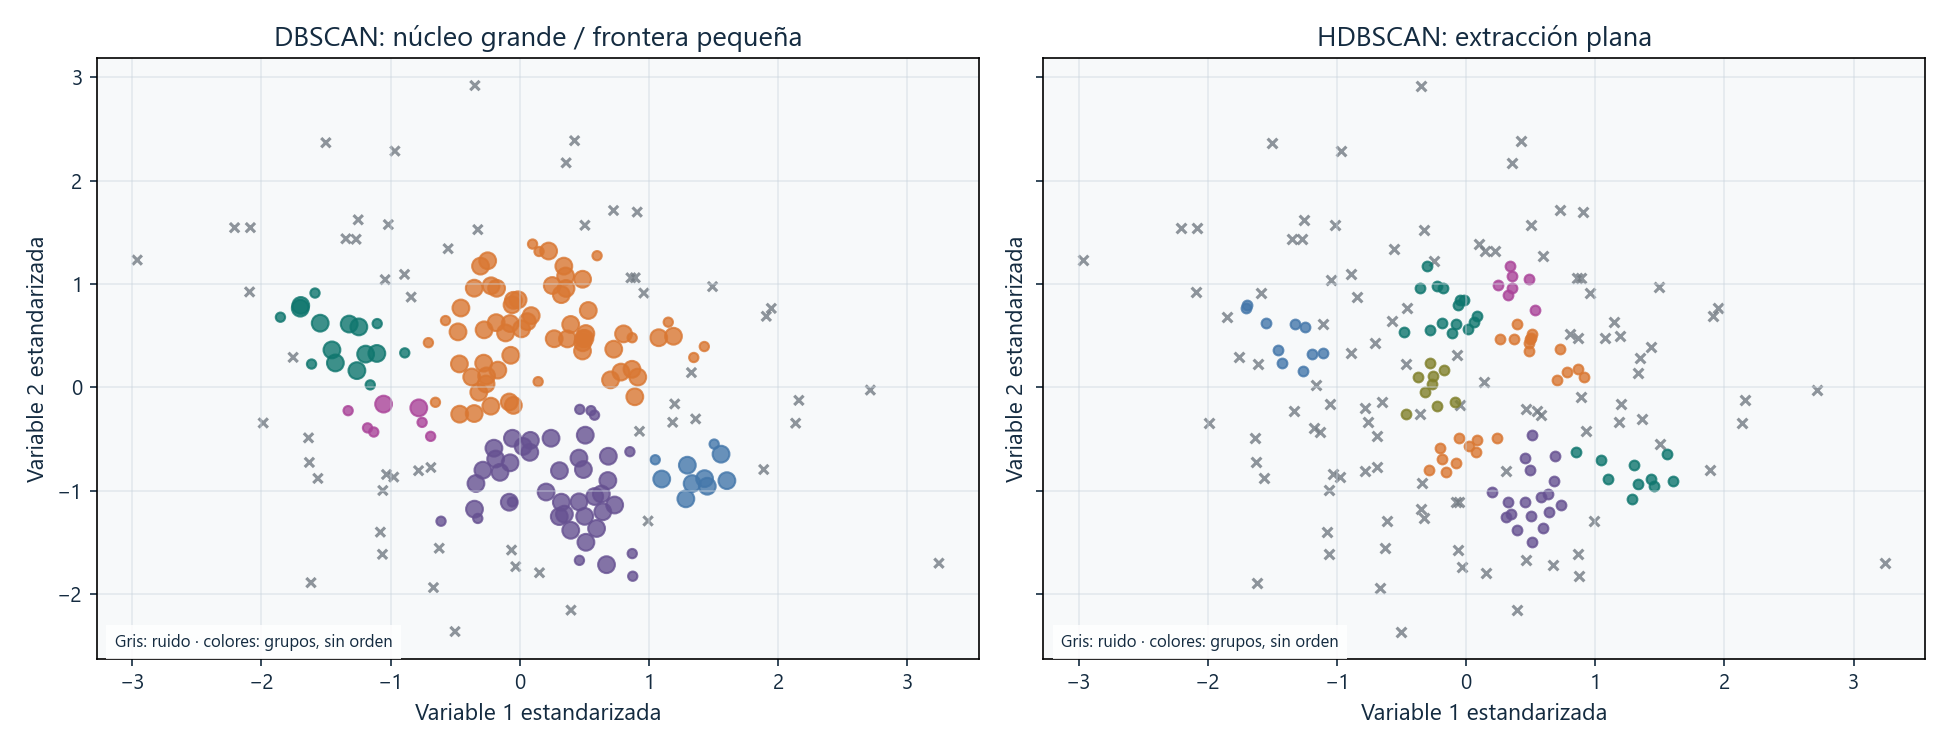

In [6]:
# Las llamadas principales quedan visibles, no escondidas en el apoyo reutilizable.
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
hdbscan = HDBSCAN(min_cluster_size=5, min_samples=5, cluster_selection_epsilon=0.0)
labels_hd = hdbscan.fit_predict(X_scaled)
core = np.zeros(len(X_scaled), dtype=bool)
core[dbscan.core_sample_indices_] = True
tipos = {'nucleo': int(core.sum()), 'frontera': int(((labels_db != -1) & ~core).sum()),
         'ruido': int((labels_db == -1).sum())}
base = {'DBSCAN': apoyo.summary(labels_db), 'HDBSCAN': apoyo.summary(labels_hd)}
display(pd.DataFrame(base).T)
print('Tipos DBSCAN:', tipos)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
apoyo.plot_labels(axes[0], X_scaled, labels_db, 'DBSCAN: núcleo grande / frontera pequeña', core)
apoyo.plot_labels(axes[1], X_scaled, labels_hd, 'HDBSCAN: extracción plana')
fig.tight_layout()
fig.savefig(RUN_DIR / 'matplotlib_base.png', dpi=150)
plt.close(fig)
display(Image(width=1100, filename=str(RUN_DIR / 'matplotlib_base.png')))


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** DBSCAN obtuvo 5 grupos y 58/200=29 % de ruido; HDBSCAN, 8 grupos y 108/200=54 %. Los grupos mayores contienen 66 y 18 filas. DBSCAN: 108 núcleos + 34 fronteras + 58 ruidos conservan las 200 filas. Son particiones distintas, no exactitud medida. Pertenencia HDBSCAN no es probabilidad calibrada ni confianza estadística. ¿Puede −1 contarse como grupo?

## 3. Las doce sensibilidades de la fuente

Conservamos completas las seis configuraciones DBSCAN (celda 10) y seis HDBSCAN (celda 12), sobre **la misma** matriz escalada. Los títulos muestran parámetros y métricas calculadas. Compare paneles antes de defender un resultado: aumentar eps puede conectar zonas; endurecer mínimos puede aumentar ruido, pero el número de grupos no cambia necesariamente de manera monótona. No seleccione parámetros solo porque produzcan una figura agradable. Estas doce ejecuciones son variaciones de una práctica, no doce ejercicios independientes.

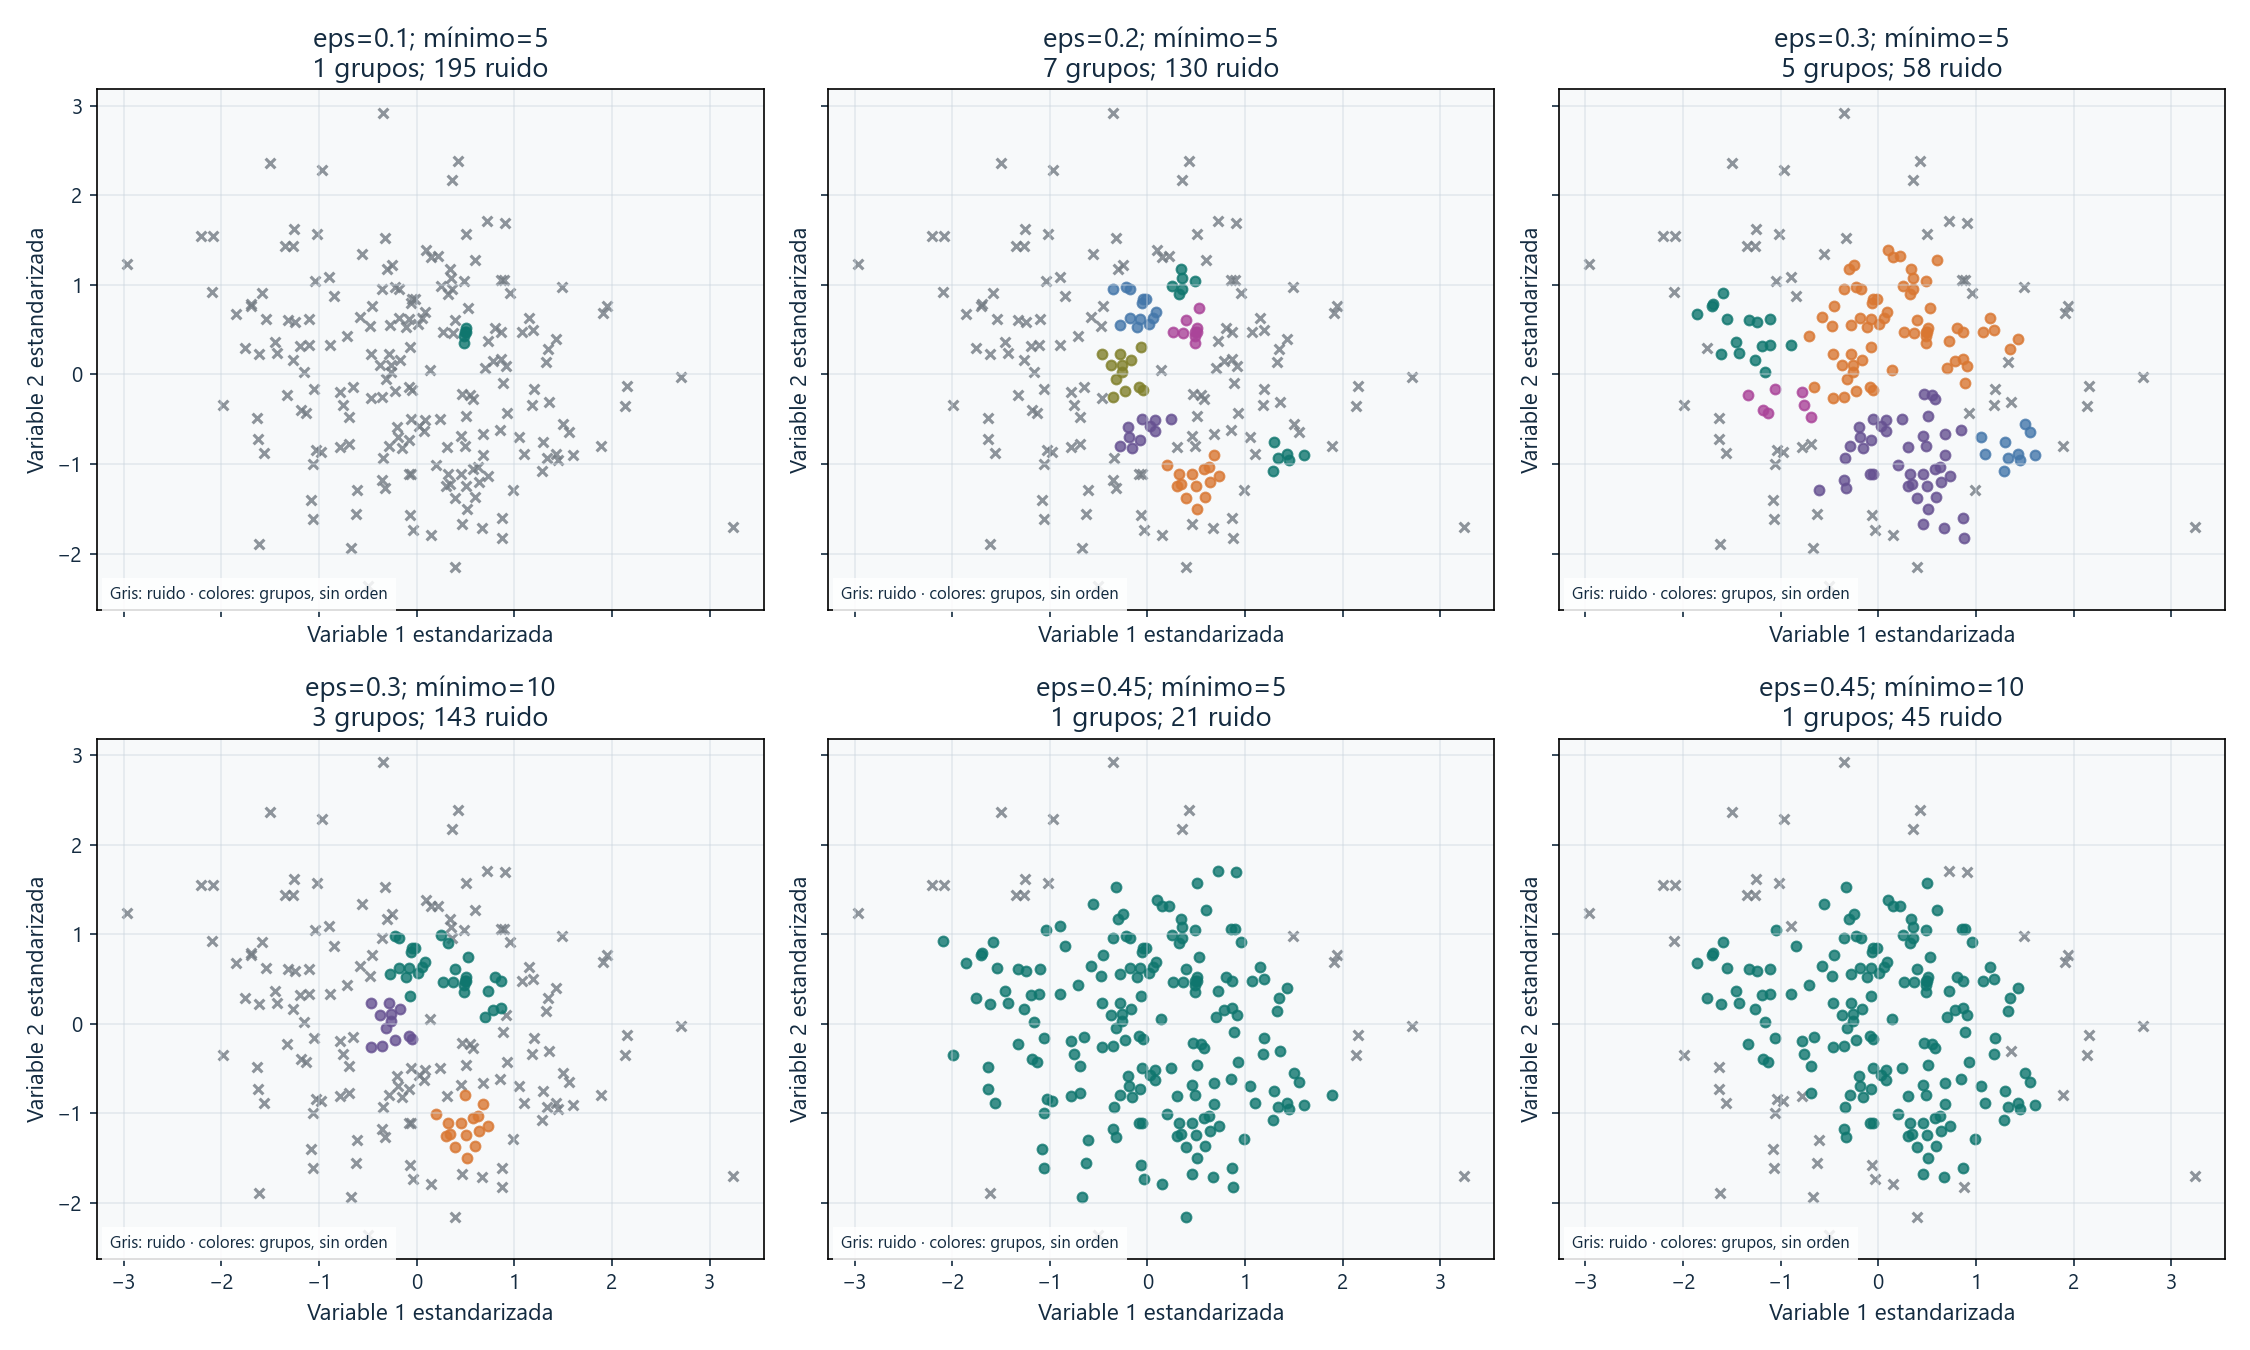

In [7]:
# Se preservan exactamente las combinaciones de la celda 10 de la fuente.
parametros_dbscan = [(0.10, 5), (0.20, 5), (0.30, 5), (0.30, 10), (0.45, 5), (0.45, 10)]
resultados = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for i, (ax, (eps, minimo)) in enumerate(zip(axes.flat, parametros_dbscan), 1):
    labels = DBSCAN(eps=eps, min_samples=minimo).fit_predict(X_scaled)
    metricas = apoyo.summary(labels)
    resultados.append({'Variante': f'DB {i}', 'eps': eps, 'min_samples': minimo, **metricas})
    titulo = f'eps={eps}; mínimo={minimo}\n{metricas["clusters"]} grupos; {metricas["ruido"]} ruido'
    apoyo.plot_labels(ax, X_scaled, labels, titulo)
fig.tight_layout()
fig.savefig(RUN_DIR / 'matplotlib_sensibilidad_dbscan.png', dpi=150)
plt.close(fig)
display(Image(width=1100, filename=str(RUN_DIR / 'matplotlib_sensibilidad_dbscan.png')))


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** DB 1 (eps=0.10, mínimo 5) deja 195/200=97.5 % de ruido; DB 5 (eps=0.45, mínimo 5), 21/200=10.5 %. Mayor radio local conecta más puntos, pero un grupo no es automáticamente mejor explicación. ¿Qué parámetro se mantuvo para comparar?

### HDBSCAN: tamaño, densidad y extracción

Lea `min_cluster_size` como tamaño mínimo de grupo, `min_samples` como control de densidad y epsilon de selección como umbral adicional de fusión. Las configuraciones cambian factores distintos; no atribuya a un solo parámetro diferencias entre paneles que cambian dos. Los ejes comunes permiten comparar forma y ruido. Gris sigue siendo −1; la paleta es nominal y puede reutilizarse.

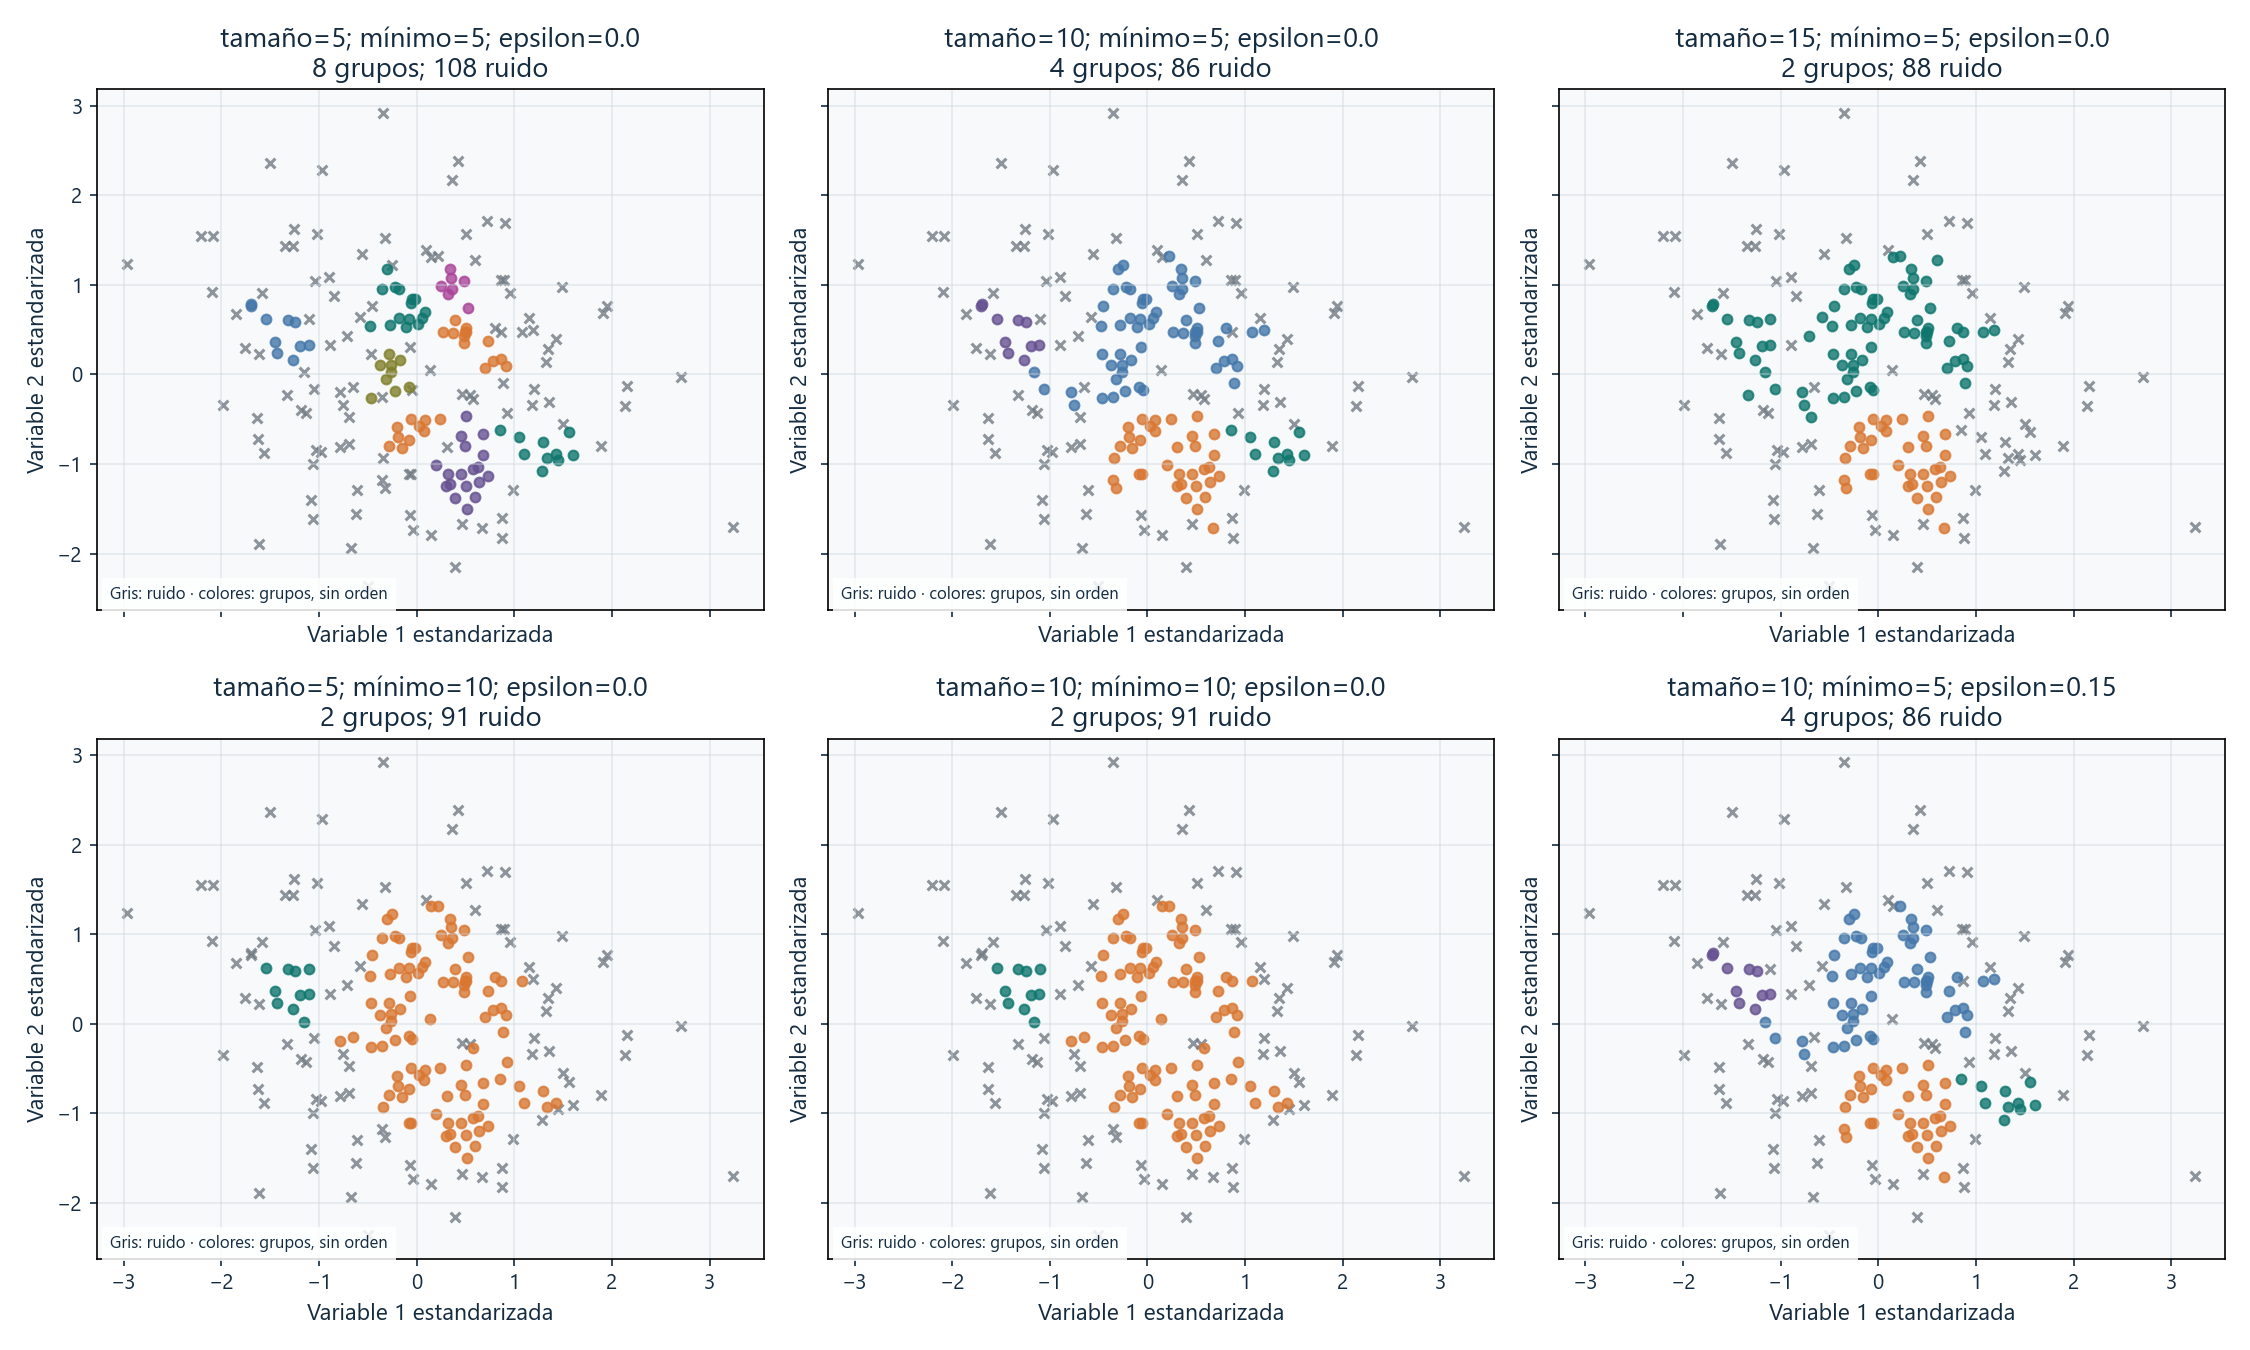

In [8]:
# Se preservan las seis ternas de la celda 12, incluido epsilon de selección 0.15.
parametros_hdbscan = [(5, 5, 0.0), (10, 5, 0.0), (15, 5, 0.0), (5, 10, 0.0), (10, 10, 0.0), (10, 5, 0.15)]
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for i, (ax, (tamano, minimo, epsilon)) in enumerate(zip(axes.flat, parametros_hdbscan), 1):
    labels = HDBSCAN(min_cluster_size=tamano, min_samples=minimo, cluster_selection_epsilon=epsilon).fit_predict(X_scaled)
    metricas = apoyo.summary(labels)
    resultados.append({'Variante': f'HD {i}', 'min_cluster_size': tamano, 'min_samples': minimo, 'cluster_selection_epsilon': epsilon, **metricas})
    titulo = f'tamaño={tamano}; mínimo={minimo}; epsilon={epsilon}\n{metricas["clusters"]} grupos; {metricas["ruido"]} ruido'
    apoyo.plot_labels(ax, X_scaled, labels, titulo)
fig.tight_layout()
fig.savefig(RUN_DIR / 'matplotlib_sensibilidad_hdbscan.png', dpi=150)
plt.close(fig)
display(Image(width=1100, filename=str(RUN_DIR / 'matplotlib_sensibilidad_hdbscan.png')))


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** HD 1 produce 8 grupos/108 ruidos; HD 2, 4/86. Cambió tamaño mínimo de 5 a 10, no una medida de exactitud. HD 2 y HD 6 muestran 4/86: iguales conteos no demuestran iguales miembros. ¿Qué comparación adicional exigiría?

### Resumen tabular ArcGIS de sensibilidad

Las barras siguientes resumen grupos y ruido en paneles independientes para no mezclar magnitudes. DB 1–6 y HD 1–6 corresponden al orden anterior; no son categorías ordinales de calidad. Menos ruido no demuestra mejor modelo. CSV agrega métricas, sin referencia espacial.

Esri Pro 3.6, [Bar, x/y/aggregation y exportToPNG](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/bar.htm), consultado por el orquestador el 15/09/2026: x categórico, y numérico, parámetros opcionales por nombre. Las figuras son PNG nativos ArcGIS, no reemplazos Matplotlib.

,Variante,eps,min_samples,filas,clusters,ruido,porcentaje_ruido,mayor_cluster,min_cluster_size,cluster_selection_epsilon
0,DB 1,0.1,5,200,1,195,97.5,5,No aplica,No aplica
1,DB 2,0.2,5,200,7,130,65.0,14,No aplica,No aplica
2,DB 3,0.3,5,200,5,58,29.0,66,No aplica,No aplica
3,DB 4,0.3,10,200,3,143,71.5,30,No aplica,No aplica
4,DB 5,0.45,5,200,1,21,10.5,179,No aplica,No aplica
5,DB 6,0.45,10,200,1,45,22.5,155,No aplica,No aplica
6,HD 1,No aplica,5,200,8,108,54.0,18,5.0,0.0
7,HD 2,No aplica,5,200,4,86,43.0,59,10.0,0.0
8,HD 3,No aplica,5,200,2,88,44.0,77,15.0,0.0
9,HD 4,No aplica,10,200,2,91,45.5,99,5.0,0.0


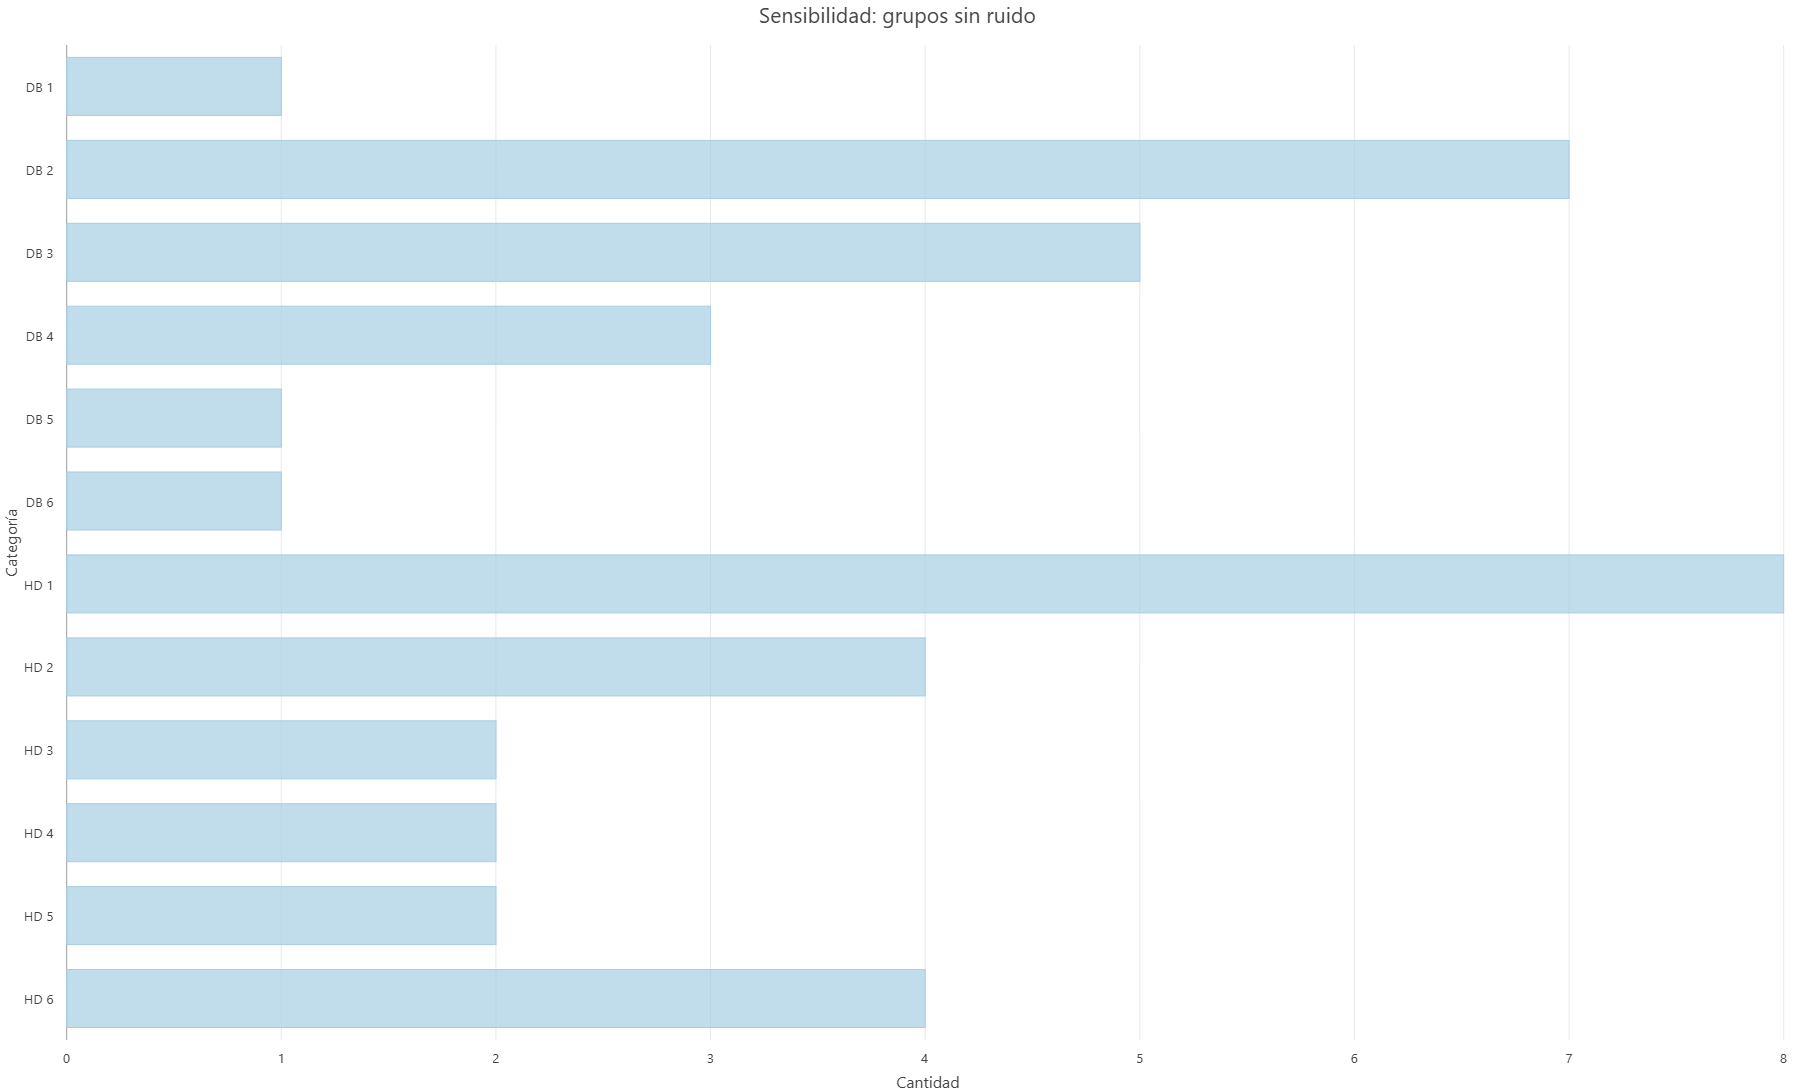

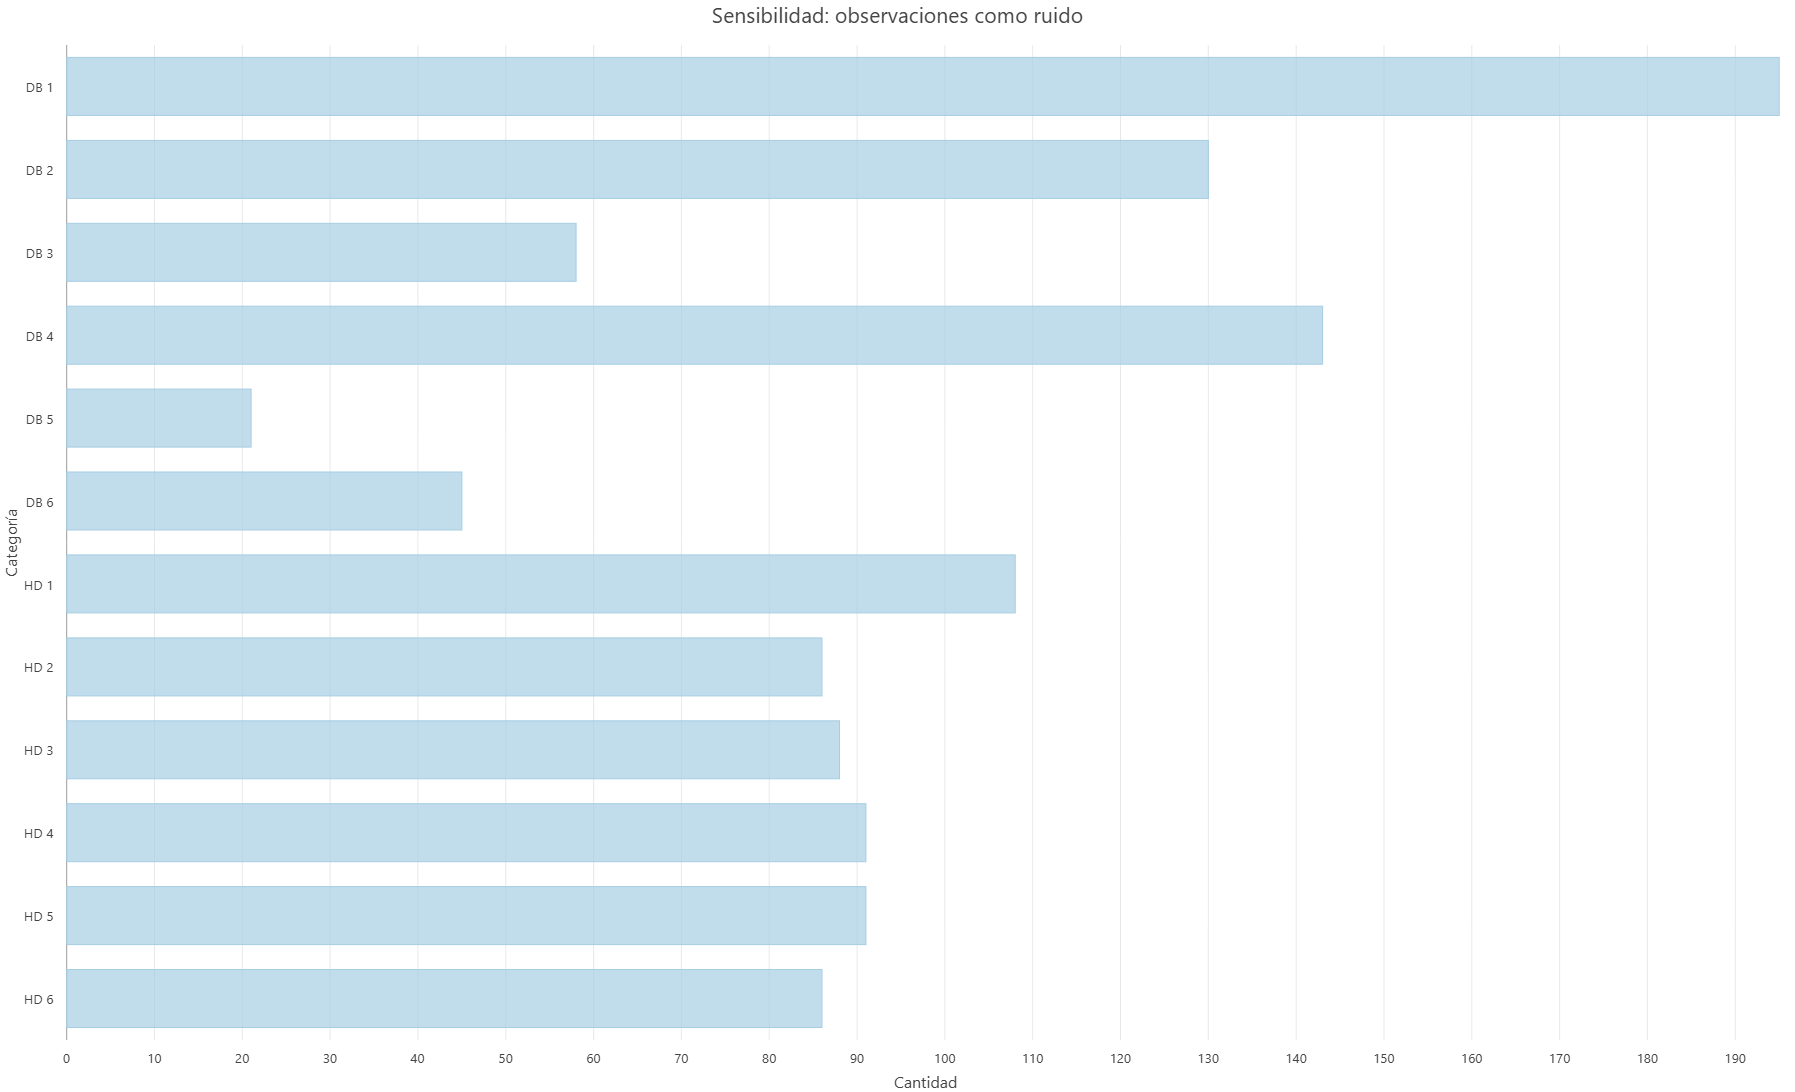

In [9]:
# Dos gráficos nativos separan número de grupos de cantidad de observaciones como ruido.
sensibilidad = pd.DataFrame(resultados)
sensibilidad.to_csv(RUN_DIR / 'sensibilidad.csv', index=False)
display(sensibilidad.fillna('No aplica'))
for campo, titulo in [('clusters', 'Sensibilidad: grupos sin ruido'), ('ruido', 'Sensibilidad: observaciones como ruido')]:
    path = apoyo.bar_csv(sensibilidad[['Variante', campo]], RUN_DIR, 'arcgis_sensibilidad_' + campo, 'Variante', campo, titulo)
    display(Image(width=1100, filename=str(path)))


**Clave de variantes:** DB 1–6 corresponden, en orden, a (eps, mínimo): (0.10,5), (0.20,5), (0.30,5), (0.30,10), (0.45,5), (0.45,10). HD 1–6 corresponden a (tamaño mínimo, mínimo de vecinos, epsilon de selección): (5,5,0), (10,5,0), (15,5,0), (5,10,0), (10,10,0), (10,5,0.15). Los identificadores son nombres, no rangos de calidad.

**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** Las barras separan número de grupos de número de filas: DB 3=5 grupos/58 ruidos y HD 1=8/108; denominador 200. Porcentaje_ruido=100×ruido/filas; mayor_cluster cuenta miembros del grupo más grande, no calidad. ¿Por qué no comparar directamente altura de grupos y observaciones?

## 4. Variar un factor a la vez

**Adaptación controlada** de la secuencia manual de V13, no afirmación de que estas realizaciones exactas se ejecutaran en video. Dos familias: (a) noise = 0, 0.2, 0.8 y base 0.9999 con N=200; (b) N = 200, 500, 1000 manteniendo noise=0.9999. Semilla fija 10 y parámetros base constantes. Cada conjunto se estandariza de forma independiente. Cambiar N genera otra realización, no garantiza un subconjunto anidado ni aísla toda variabilidad muestral.

Cada fila de la figura corresponde a un conjunto; DBSCAN y HDBSCAN usan los mismos puntos dentro de esa fila. Compare ruido y forma, sin equiparar IDs entre paneles. El título informa factores y ruido medido. Se conserva la perturbación base como control.

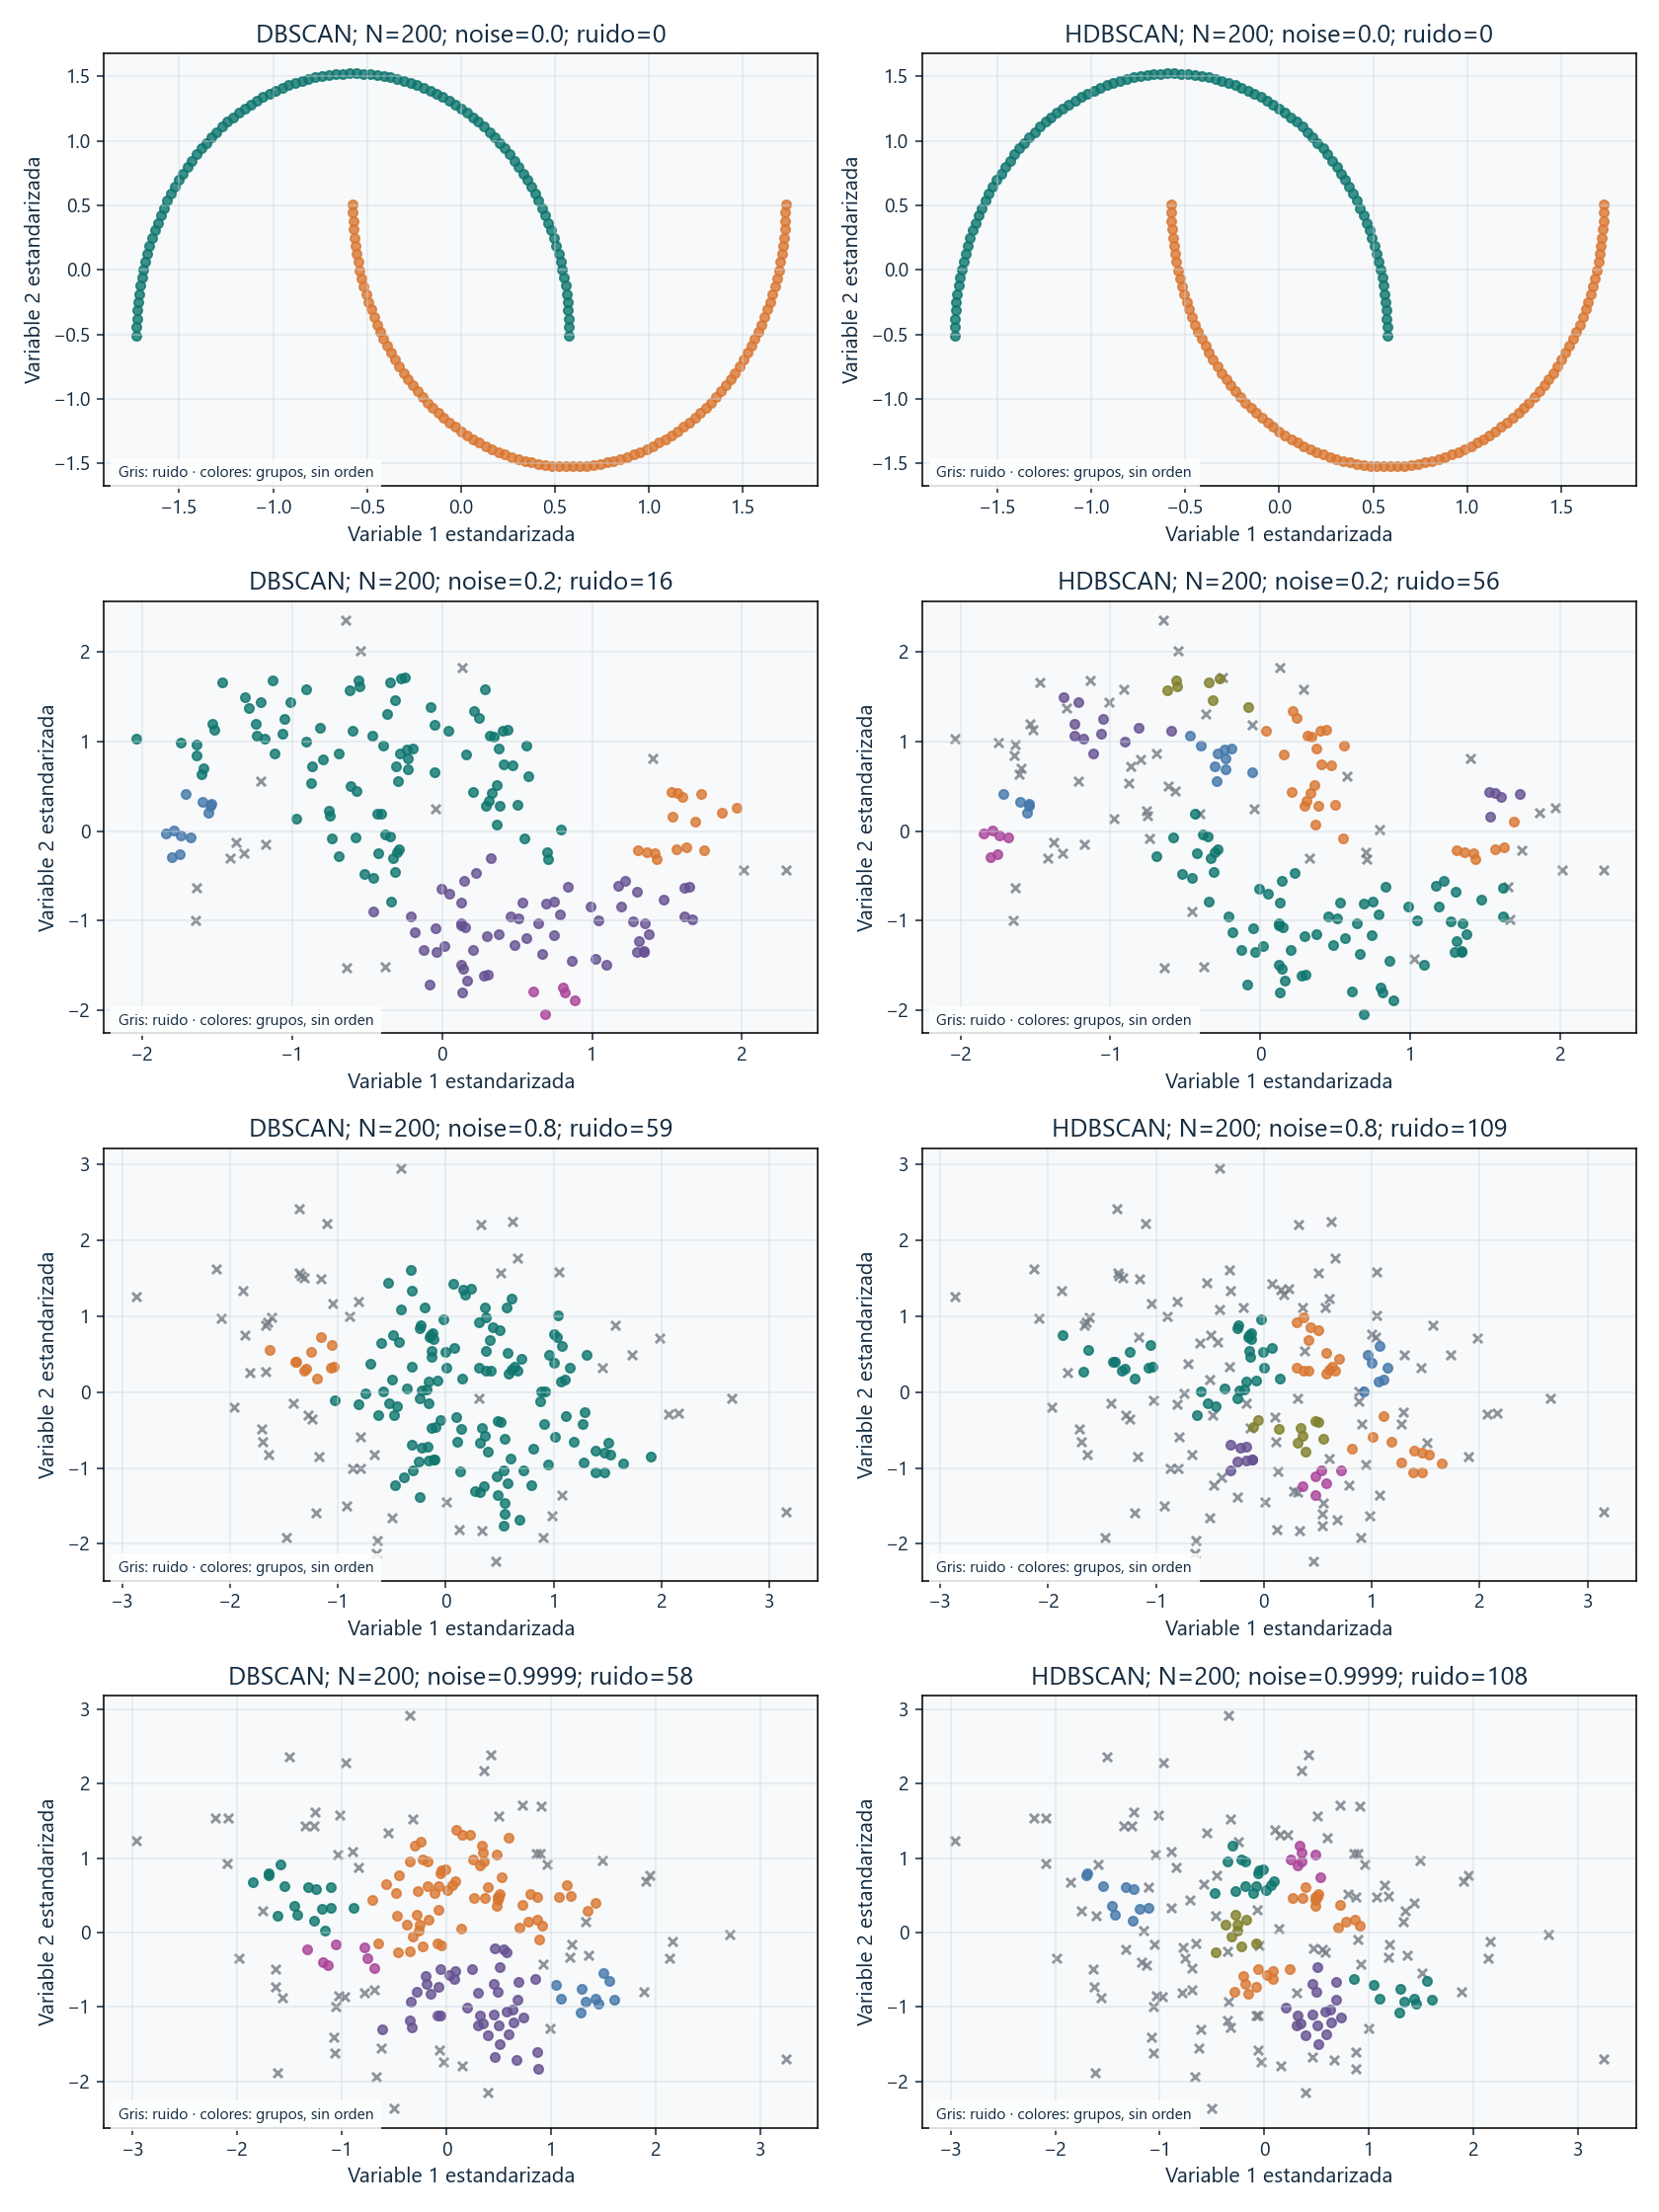

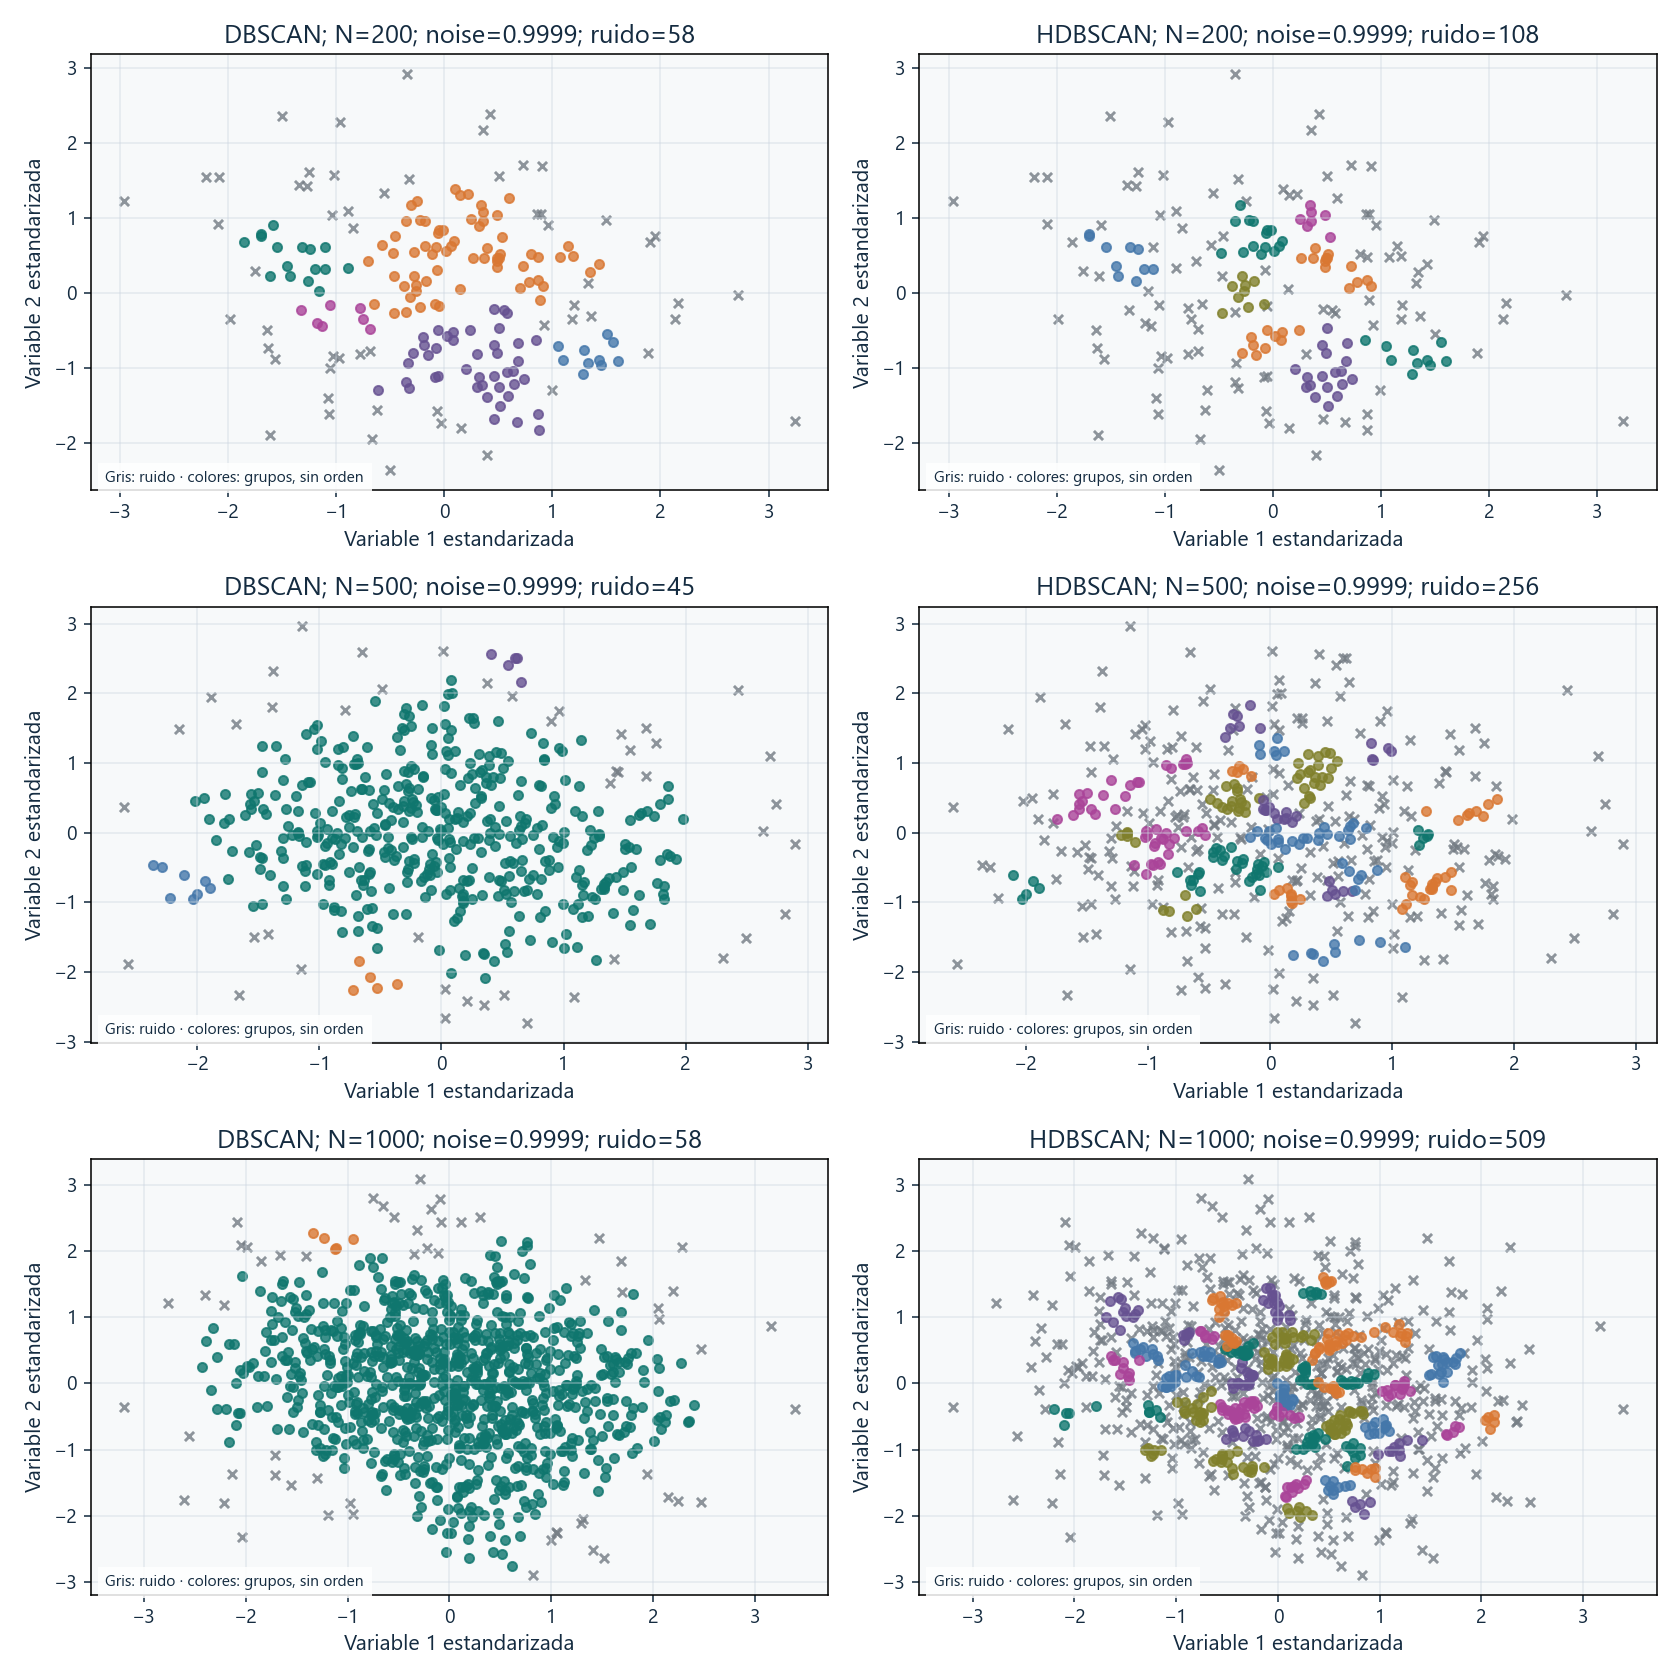

In [10]:
# Cada familia modifica únicamente ruido generador o tamaño; no se añaden ejercicios.
experimentos = [(200, r, 'Ruido') for r in [0.0, 0.2, 0.8, 0.9999]] + [(n, 0.9999, 'Muestra') for n in [200, 500, 1000]]
controlados = []
for familia in ['Ruido', 'Muestra']:
    casos = [e for e in experimentos if e[2] == familia]
    fig, axes = plt.subplots(len(casos), 2, figsize=(12, 4 * len(casos)))
    for fila, (n, perturbacion, _) in enumerate(casos):
        datos, _ = make_moons(n_samples=n, noise=perturbacion, random_state=10)
        valores = StandardScaler().fit_transform(datos)
        modelos = [('DBSCAN', DBSCAN(eps=0.3, min_samples=5)), ('HDBSCAN', HDBSCAN(min_cluster_size=5, min_samples=5, cluster_selection_epsilon=0.0))]
        for col, (nombre, modelo) in enumerate(modelos):
            labels = modelo.fit_predict(valores)
            metrica = apoyo.summary(labels)
            controlados.append({'familia': familia, 'n': n, 'noise': perturbacion, 'metodo': nombre, **metrica})
            apoyo.plot_labels(axes[fila, col], valores, labels, f'{nombre}; N={n}; noise={perturbacion}; ruido={metrica["ruido"]}')
    fig.tight_layout()
    path = RUN_DIR / ('matplotlib_control_' + familia.lower() + '.png')
    fig.savefig(path, dpi=140)
    plt.close(fig)
    display(Image(width=1100, filename=str(path)))


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** Sin perturbación, ambos métodos dieron 2 grupos/0 ruidos con 200 filas. Con noise=0.9999 y N=1000, DBSCAN deja 58/1000=5.8 % de ruido y HDBSCAN 509/1000=50.9 %. Son otras realizaciones estandarizadas, no mejora garantizada al aumentar N. ¿En qué difieren perturbación generadora y etiqueta −1?

## 5. Interpretar sin convertir sensibilidad en certeza

La tabla final permite comprobar qué configuraciones cambian asignación y ruido. Compare valores reales, no resultados históricos. Más observaciones modifican la densidad empírica aun manteniendo parámetros; más perturbación puede desdibujar las lunas. Ninguna de estas tendencias garantiza monotonicidad en toda realización.

**Actividad de lectura:** elija dos variantes que cambien solo eps; explique qué puntos cambian y por qué un grupo puede extenderse más que eps. Después contraste ruido generador con ruido −1. No use `probabilities_` como significancia estadística ni pretenda que las etiquetas muestran toda la jerarquía.

**Data Engineering manual, no ejecutado aquí:** abrir las tablas locales generadas, revisar campos, nulos y estadísticas; no aplicar limpieza automática. La automatización efectivamente ejecutada corresponde a Field Statistics To Table y gráficos ArcGIS. Las salidas sintetizan este experimento, no validan una aplicación territorial. La nota de clase y los conceptos se prepararán después de revisar resultados.

In [11]:
# Evidencia agregada y figuras locales; no se usan entradas ni salidas de otra práctica.
pd.DataFrame(controlados).to_csv(RUN_DIR / 'experimentos_controlados.csv', index=False)
display(pd.DataFrame(controlados))
evidencia = {'practica': '01', 'estado': 'ejecutado', 'segundos': time.perf_counter() - inicio,
             'sintetica_exclusiva': True, 'n_samples': len(X), 'noise': 0.9999, 'random_state': 10,
             'base': base, 'tipos_dbscan': tipos, 'sensibilidades': resultados, 'controlados': controlados,
             'perfil_arcgis': 'trabajo.gdb/perfil_lunas', 'mapas': 'No aplican: excepción humana acotada P01'}
apoyo.write_evidence(RUN_DIR, evidencia)
print('Evidencia agregada guardada. Duración en segundos:', round(evidencia['segundos'], 2))


Evidencia agregada guardada. Duración en segundos: 11.47


,familia,n,noise,metodo,filas,clusters,ruido,porcentaje_ruido,mayor_cluster
0,Ruido,200,0.0000,DBSCAN,200,2,0,0.0,100
1,Ruido,200,0.0000,HDBSCAN,200,2,0,0.0,100
2,Ruido,200,0.2000,DBSCAN,200,5,16,8.0,94
3,Ruido,200,0.2000,HDBSCAN,200,10,56,28.0,60
4,Ruido,200,0.8000,DBSCAN,200,2,59,29.5,130
5,Ruido,200,0.8000,HDBSCAN,200,8,109,54.5,23
6,Ruido,200,0.9999,DBSCAN,200,5,58,29.0,66
7,Ruido,200,0.9999,HDBSCAN,200,8,108,54.0,18
8,Muestra,200,0.9999,DBSCAN,200,5,58,29.0,66
9,Muestra,200,0.9999,HDBSCAN,200,8,108,54.0,18


**Lectura histórica conservada — referencia histórica; salida actual arriba/abajo.** Con N=500 y perturbación 0.9999, DBSCAN registra 4 grupos/45 ruidos; HDBSCAN 24/256: 9 % frente a 51.2 %. Los 40.36 s almacenados corresponden a aquella corrida, no agenda ni rendimiento medido hoy. Conclusión: tamaño y reglas cambian la partición, no prueban exactitud. ¿Qué faltaría para evaluar una predicción real?